In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [29]:
# Cell 2: Load Dataset
# Đường dẫn tương đối từ thư mục notebooks/ đến thư mục data/
DATA_PATH = '../Dataset/raw/Attack_Dataset.csv' 

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Kích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.")
    display(df.head())
except FileNotFoundError:
    print(f"Không tìm thấy file tại {DATA_PATH}. Vui lòng kiểm tra lại đường dẫn!")

Kích thước tập dữ liệu: 14133 dòng, 16 cột.


,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 – Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",NaN
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 – SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",NaN


In [ ]:
# Cell 3
print("1. Thông tin các cột và kiểu dữ liệu:")
df.info()
print("-" * 50)

print("2. Thống kê số lượng giá trị bị thiếu (Null/NaN):")
print(df.isnull().sum())


1. Thông tin các cột và kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    14133 non-null  int64 
 1   Title                 14133 non-null  object
 2   Category              14133 non-null  object
 3   Attack Type           14133 non-null  object
 4   Scenario Description  14133 non-null  object
 5   Tools Used            14119 non-null  object
 6   Attack Steps          14133 non-null  object
 7   Target Type           14129 non-null  object
 8   Vulnerability         14115 non-null  object
 9   MITRE Technique       14109 non-null  object
 10  Impact                14130 non-null  object
 11  Detection Method      14129 non-null  object
 12  Solution              14130 non-null  object
 13  Tags                  14130 non-null  object
 14  Source                13973 non-null  object
 15

In [31]:

print(f"Tổng số dòng ban đầu: {df.shape[0]} dòng\n")

# =====================================================================
# A. CHỈ RA VẤN ĐỀ LỆCH CỘT (COLUMN SHIFTING)
# =====================================================================
print("--- A. KIỂM TRA LỆCH CỘT ---")

# Kiểu 1 & 2: Dữ liệu bị đẩy tràn ra cột Unnamed: 15
type_unnamed = df[df['Unnamed: 15'].notnull()]
print(f"1. Số dòng bị đẩy tràn sang cột 'Unnamed: 15': {len(type_unnamed)} dòng")
if len(type_unnamed) > 0:
    display(type_unnamed[['ID', 'Title', 'MITRE Technique', 'Impact', 'Unnamed: 15']].head(3))

# Kiểu 3: Mã MITRE ID bị lệch sang cột Impact do lỗi nháy kép (")
mitre_in_impact = df[df['Impact'].astype(str).str.contains(r'^T\d{4}', na=False)]
print(f"\n2. Số dòng bị lệch mã MITRE ID sang cột 'Impact': {len(mitre_in_impact)} dòng")
if len(mitre_in_impact) > 0:
    display(mitre_in_impact[['ID', 'Title', 'MITRE Technique', 'Impact']].head(3))

# Kiểu 4: Các bước thực hiện (Steps / HTML <br>) lọt vào cột Target Type / Vulnerability
steps_in_wrong_cols = df[
    df['Target Type'].astype(str).str.contains(r'Step \d+|<br>', na=False) |
    df['Vulnerability'].astype(str).str.contains(r'Step \d+|<br>', na=False)
]
print(f"\n3. Số dòng bị lệch phần 'Attack Steps' sang Target Type / Vulnerability: {len(steps_in_wrong_cols)} dòng")
if len(steps_in_wrong_cols) > 0:
    display(steps_in_wrong_cols[['ID', 'Title', 'Target Type', 'Vulnerability']].head(3))


# =====================================================================
# B. CHỈ RA VẤN ĐỀ TRÙNG LẶP (DUPLICATES)
# =====================================================================
print("\n--- B. KIỂM TRA TRÙNG LẶP NỘI DUNG ---")
# Loại trừ ID và Unnamed: 15 để kiểm tra tính trùng lặp thực tế của nội dung
content_cols = [c for c in df.columns if c not in ['ID', 'Unnamed: 15']]
dup_count = df.duplicated(subset=content_cols).sum()
print(f"Số dòng trùng lặp nội dung hoàn toàn: {dup_count} dòng")

# Hiển thị ví dụ một nhóm trùng lặp
dup_rows = df[df.duplicated(subset=content_cols, keep=False)].sort_values(by='Title')
if len(dup_rows) > 0:
    print("\nVí dụ về các dòng trùng lặp nội dung (khác nhau ID):")
    display(dup_rows[['ID', 'Title', 'Category']].head(4))


Tổng số dòng ban đầu: 14133 dòng

--- A. KIỂM TRA LỆCH CỘT ---
1. Số dòng bị đẩy tràn sang cột 'Unnamed: 15': 46 dòng


,ID,Title,MITRE Technique,Impact,Unnamed: 15
5055,5056,Fake Shutdown Command to PLC,Insecure protocol with no auth,T0884,Educational Simulation
5056,5057,Forge Response Data to Fake Safe Readings,Trust-based communication,T0855,Educational Simulation
5057,5058,Spoof Sensor Failures to Trigger Emergency,No source identity check,T0856,Educational Simulation



2. Số dòng bị lệch mã MITRE ID sang cột 'Impact': 116 dòng


,ID,Title,MITRE Technique,Impact
521,522,Intent Hijacking via Malicious Activity,Insecure usage of implicit intents,T1411 – Intent Spoofing
1293,1294,AI-as-Tool Exploitation,LLM output is blindly trusted in automation stack,T1203 – Exploitation via Script Injection
2037,2038,Command Injection in URL/Param,Backend improperly handles param in shell context,T1059.001 – Command Execution via Shell



3. Số dòng bị lệch phần 'Attack Steps' sang Target Type / Vulnerability: 47 dòng


,ID,Title,Target Type,Vulnerability
447,448,Logs Containing Sensitive Data,grep -i tokenoradb logcat,grep -i passwordto capture logs. Step 4: If cr...
484,485,Rename Root Binaries & Paths,grep suandls,grep busybox. Step 5: Temporarily rename these...
1293,1294,AI-as-Tool Exploitation,bash`. Step 7: This bypasses the LLM's own fil...,LLM-as-helper + execution toolchain



--- B. KIỂM TRA TRÙNG LẶP NỘI DUNG ---
Số dòng trùng lặp nội dung hoàn toàn: 238 dòng

Ví dụ về các dòng trùng lặp nội dung (khác nhau ID):


,ID,Title,Category
6128,6129,.hta Script via Email,Insider Threat
6073,6074,.hta Script via Email,Insider Threat
10535,10536,AWS Access Key Found in GitLab Public Project,DevSecOps & CI/CD Security
10545,10546,AWS Access Key Found in GitLab Public Project,DevSecOps & CI/CD Security


In [32]:
# Cell 3.1: Làm sạch dữ liệu, Hiệu chỉnh lệch cột & Xử lý trùng lặp
import re
print(f"Kích thước ban đầu: {df.shape}")

# =====================================================================
# 1. HIỆU CHỈNH LỆCH CỘT (COLUMN REALIGNMENT)
# =====================================================================
df_corr = df.copy()
cols_list = list(df_corr.columns)
target_idx = cols_list.index('MITRE Technique')
mitre_pattern = re.compile(r'\bT\d{4}(?:\.\d{3})?\b')
corrected_count = 0

for idx, row in df_corr.iterrows():
    # Kiểu 1: 45 dòng SCADA (lặp Tools Used sang Target Type, đẩy Source sang Unnamed: 15)
    if row['Unnamed: 15'] == 'Educational Simulation':
        cols_scada = ['Target Type', 'Vulnerability', 'MITRE Technique', 'Impact', 'Detection Method', 'Solution', 'Tags', 'Source', 'Unnamed: 15']
        df_corr.loc[idx, cols_scada[:-1]] = [row[c] for c in cols_scada[1:]]
        df_corr.at[idx, 'Unnamed: 15'] = None
        corrected_count += 1
        continue

    # Kiểu 2 & 3: Lệch cột do dấu phẩy kép hoặc lỗi nháy kép (") phân tách sai cột
    mitre_col = None
    for col in ['Impact', 'Detection Method', 'Solution', 'Tags', 'Source', 'Unnamed: 15']:
        val = str(row[col])
        if mitre_pattern.search(val):
            # Tránh nhận nhầm các tag tham chiếu MITRE ID phụ ở Source/Tags của các dòng chuẩn
            has_correct_mitre = pd.notnull(row['MITRE Technique']) and bool(mitre_pattern.search(str(row['MITRE Technique'])))
            if col in ['Source', 'Tags'] and has_correct_mitre:
                continue
            mitre_col = col
            break
            
    if mitre_col:
        current_idx = cols_list.index(mitre_col)
        shift_amount = current_idx - target_idx
        
        if shift_amount > 0:
            # Gộp các mảnh của cột Attack Steps bị cắt nhỏ do dấu phẩy thừa
            merge_cols = ['Attack Steps '] + cols_list[cols_list.index('Attack Steps ')+1 : cols_list.index('Attack Steps ')+1+shift_amount]
            merged_steps = ", ".join([str(row[c]) for c in merge_cols if pd.notnull(row[c]) and str(row[c]) != ''])
            
            # Dịch chuyển ngược các cột Target Type trở đi sang bên trái
            start_shift_idx = cols_list.index('Target Type')
            shift_cols = cols_list[start_shift_idx : -1]
            
            new_row_values = {}
            for i, target_col in enumerate(shift_cols):
                src_col_idx = start_shift_idx + i + shift_amount
                if src_col_idx < len(cols_list):
                    new_row_values[target_col] = row[cols_list[src_col_idx]]
                else:
                    new_row_values[target_col] = None
            
            # Gán lại các giá trị đã dịch chuyển
            for target_col, val in new_row_values.items():
                df_corr.at[idx, target_col] = val
                
            df_corr.at[idx, 'Attack Steps '] = merged_steps
            df_corr.at[idx, 'Unnamed: 15'] = None
            corrected_count += 1

df = df_corr
print(f"Đã sửa và căn chỉnh lại thành công {corrected_count} dòng bị lệch cột.")

# =====================================================================
# 2. LOẠI BỎ CỘT PHỤ & ĐIỀN THIẾU
# =====================================================================
# Xóa cột rác 'Unnamed: 15'
if 'Unnamed: 15' in df.columns:
    df = df.drop(columns=['Unnamed: 15'])

# Xóa các dòng bị thiếu nhãn (MITRE Technique)
df = df.dropna(subset=['MITRE Technique'])

# Điền giá trị rỗng cho các trường rỗng còn lại
df = df.fillna('')

# =====================================================================
# 3. LOẠI BỎ DÒNG TRÙNG LẶP NỘI DUNG (DEDUPLICATION)
# =====================================================================
# Định nghĩa các cột nội dung cần kiểm tra trùng lặp (không xét cột ID)
content_cols = [c for c in df.columns if c not in ['ID']]
before_dedup = df.shape[0]
df = df.drop_duplicates(subset=content_cols)
print(f"Đã xóa {before_dedup - df.shape[0]} dòng trùng lặp hoàn toàn về nội dung.")

print(f"Kích thước tập dữ liệu sau khi làm sạch: {df.shape}")


Kích thước ban đầu: (14133, 16)
Đã sửa và căn chỉnh lại thành công 128 dòng bị lệch cột.
Đã xóa 234 dòng trùng lặp hoàn toàn về nội dung.
Kích thước tập dữ liệu sau khi làm sạch: (13876, 15)


In [33]:
# Cell 3.2: Gộp các cột nội dung thành một cột 'text' duy nhất
# Bạn có thể tùy chỉnh các cột được gộp dựa trên đánh giá chuyên môn của mình
df.columns = df.columns.str.strip()

df['text'] = (
    df['Title'].astype(str) + ". " + 
    df['Scenario Description'].astype(str) + " " + 
    df['Attack Steps'].astype(str) + " " + 
    "Tools: " + df['Tools Used'].astype(str)
)

# Đổi tên cột MITRE Technique thành 'label' để tiện cho các code EDA phía sau
df = df.rename(columns={'MITRE Technique': 'label'})

print("Dữ liệu mẫu sau khi gộp tạo cột 'text':")
display(df[['text', 'label']].head())

Dữ liệu mẫu sau khi gộp tạo cột 'text':


,text,label
0,Authentication Bypass via SQL Injection. A log...,"T1078 (Valid Accounts), T1190 (Exploit Public-..."
1,Union-Based SQL Injection. This attack occurs ...,T1190 – Exploit Public-Facing Application
2,Error-Based SQL Injection. This attack occurs ...,T1190 – Exploit Public-Facing Application
3,"Blind SQL Injection. In Blind SQL Injection, t...",T1190 – Exploit Public-Facing Application
4,Second-Order SQL Injection. In a Second-Order ...,T1505.003 – SQL Injection


In [34]:
# Cell 4: Thống kê và trực quan hóa phân phối nhãn


# Đếm số lượng mẫu cho từng nhãn (Kỹ thuật MITRE ATT&CK)
label_counts = df['label'].value_counts()

# In ra các số liệu thống kê dạng text
print(f"Tổng số lượng kỹ thuật (classes) duy nhất: {len(label_counts)}")
print("-" * 50)
print("Top 10 kỹ thuật xuất hiện nhiều nhất (Majority classes):")
print(label_counts.head(10))
print("\nTop 5 kỹ thuật xuất hiện ít nhất (Minority classes):")
print(label_counts.tail(5))
print("-" * 50)




Tổng số lượng kỹ thuật (classes) duy nhất: 5667
--------------------------------------------------
Top 10 kỹ thuật xuất hiện nhiều nhất (Majority classes):
label
T1203                                            348
T1552.001                                        210
T1195.002                                        138
T1499                                            122
T1189                                            113
T1609                                             91
T1499 – Endpoint Denial of Service                90
T1190 – Exploit Public-Facing Application         77
T1204.002                                         76
T1203 – Exploitation for Privilege Escalation     75
Name: count, dtype: int64

Top 5 kỹ thuật xuất hiện ít nhất (Minority classes):
label
T1329                               1
T1557, T1565                        1
T0895                               1
T1606.003 – Model Deconstruction    1
T1218.007                           1
Name: count, dtype: int64
------

In [35]:
# Cell 4.1: Chuẩn hóa nhãn MITRE ATT&CK bằng Regex
import re

print(f"Số lượng nhãn duy nhất TRƯỚC khi chuẩn hóa: {df['label'].nunique()}")

# Hàm trích xuất mã MITRE ID (VD: T1203, T1552.001)
def extract_primary_mitre_id(text):
    # Tìm chuỗi bắt đầu bằng T, theo sau là 4 số, có thể có thêm . và 3 số
    match = re.search(r'T\d{4}(?:\.\d{3})?', str(text))
    return match.group(0) if match else None

# Áp dụng hàm để làm sạch cột label
df['label'] = df['label'].apply(extract_primary_mitre_id)

# Bỏ các dòng mà regex không tìm thấy mã MITRE hợp lệ (nếu có)
df = df.dropna(subset=['label'])

print(f"Số lượng nhãn duy nhất SAU khi chuẩn hóa: {df['label'].nunique()}")

# Xem lại Top 10 nhãn phổ biến
print("\nTop 10 nhãn sau khi đã gộp chung ID:")
label_counts_clean = df['label'].value_counts()
print(label_counts_clean.head(10))

Số lượng nhãn duy nhất TRƯỚC khi chuẩn hóa: 5667
Số lượng nhãn duy nhất SAU khi chuẩn hóa: 755

Top 10 nhãn sau khi đã gộp chung ID:
label
T1203        699
T1499        394
T1606        350
T1552.001    284
T1609        266
T1557        265
T1040        232
T1600        231
T1059.007    210
T1204.002    195
Name: count, dtype: int64


Số lượng nhãn (classes) TRƯỚC khi gộp: 755
Số lượng nhãn (classes) SAU khi gộp: 363
--------------------------------------------------
Số lượng nhãn có từ 10 mẫu trở lên: 154
Tổng số lượng dữ liệu (samples) còn lại để huấn luyện: 13161
--------------------------------------------------


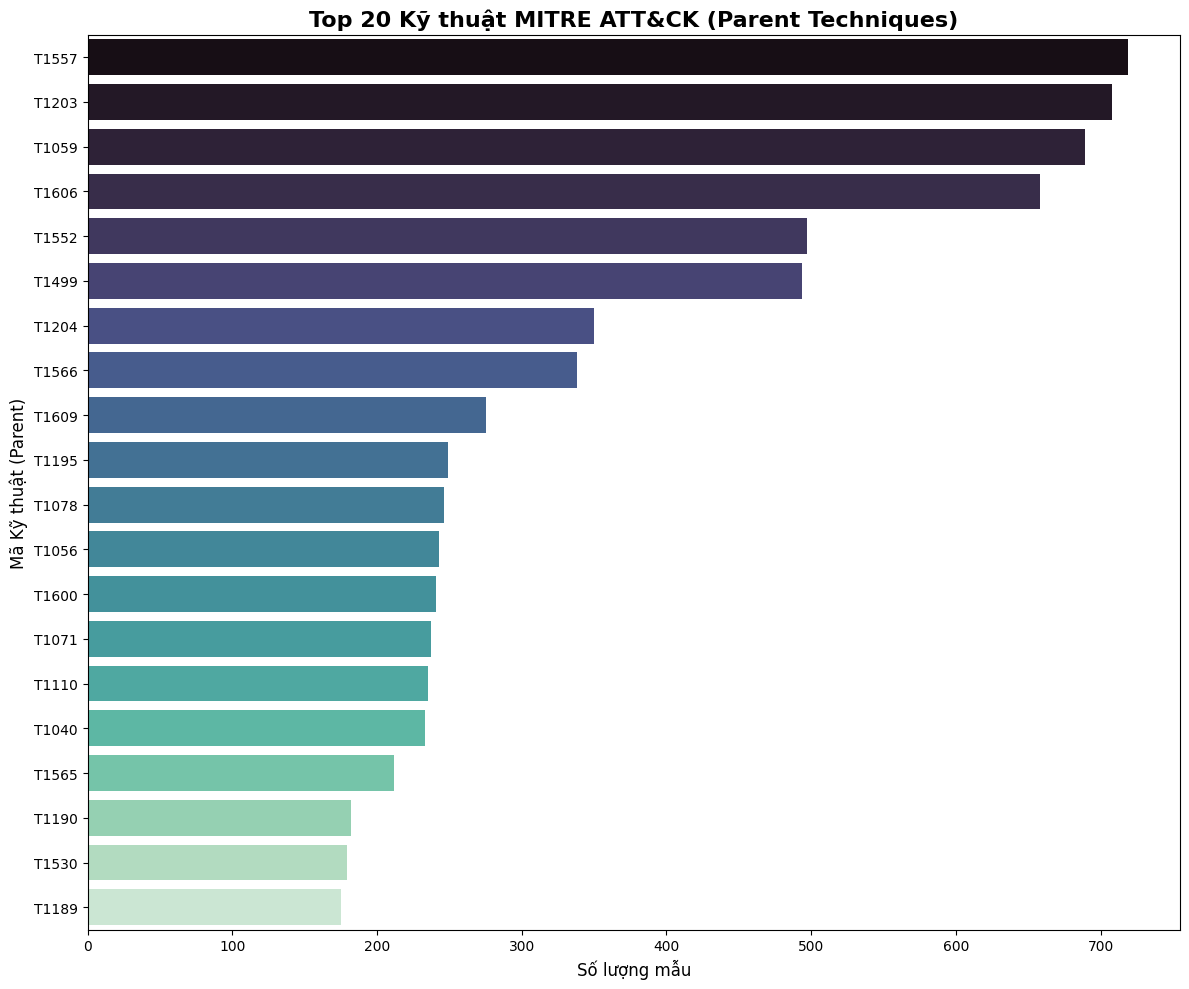

In [36]:
# Cell 5: Gộp nhãn theo phân cấp và lọc dữ liệu

print(f"Số lượng nhãn (classes) TRƯỚC khi gộp: {df['label'].nunique()}")

# 1. Hàm gộp Sub-technique về Parent Technique
# Kỹ thuật: Cắt bỏ phần đuôi từ dấu chấm trở đi (VD: 'T1552.001' -> 'T1552')
def get_parent_technique(label):
    if pd.isna(label): 
        return label
    return str(label).split('.')[0]

# Áp dụng hàm gộp
df['label'] = df['label'].apply(get_parent_technique)

print(f"Số lượng nhãn (classes) SAU khi gộp: {df['label'].nunique()}")
print("-" * 50)

# 2. Thống kê và lọc lại theo ngưỡng an toàn (Thresholding)
MIN_SAMPLES = 10  # Ngưỡng tối thiểu số mẫu cần thiết để mô hình có thể học

label_counts_grouped = df['label'].value_counts()
valid_labels = label_counts_grouped[label_counts_grouped >= MIN_SAMPLES].index

print(f"Số lượng nhãn có từ {MIN_SAMPLES} mẫu trở lên: {len(valid_labels)}")

# Lọc DataFrame, chỉ giữ lại các nhãn thỏa mãn điều kiện
df_final = df[df['label'].isin(valid_labels)].copy()

print(f"Tổng số lượng dữ liệu (samples) còn lại để huấn luyện: {df_final.shape[0]}")
print("-" * 50)

# 3. Trực quan hóa kết quả sau khi gộp và lọc
plt.figure(figsize=(12, 10))
ax = sns.barplot(
    x=df_final['label'].value_counts().head(20).values, 
    y=df_final['label'].value_counts().head(20).index, 
    hue=df_final['label'].value_counts().head(20).index, 
    palette='mako',
    legend=False
)
plt.title('Top 20 Kỹ thuật MITRE ATT&CK (Parent Techniques)', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng mẫu', fontsize=12)
plt.ylabel('Mã Kỹ thuật (Parent)', fontsize=12)
plt.tight_layout()
plt.show()



In [37]:
# Cell 6: Lọc bỏ các nhãn thiểu số (Thresholding)

# 1. Đặt ngưỡng tối thiểu
MIN_SAMPLES = 10

# 2. Đếm tần suất xuất hiện của từng nhãn hiện tại
label_counts = df['label'].value_counts()

# 3. Trích xuất danh sách các nhãn "đạt chuẩn" (>= 10 mẫu)
valid_labels = label_counts[label_counts >= MIN_SAMPLES].index

# 4. Lọc lại DataFrame, chỉ giữ những dòng có nhãn nằm trong danh sách đạt chuẩn
df_filtered = df[df['label'].isin(valid_labels)].copy()

# 5. In báo cáo kết quả
print(f"Số lượng nhãn (classes) TRƯỚC khi lọc: {len(label_counts)}")
print(f"Số lượng nhãn (classes) SAU khi lọc: {df_filtered['label'].nunique()}")
print(f"Tổng số lượng dữ liệu (samples) sẵn sàng huấn luyện: {df_filtered.shape[0]}")

# Lưu dữ liệu đã sạch sơ bộ ra file
df_filtered.to_csv('../Dataset/processed/cti_dataset_cleaned.csv', index=False)

Số lượng nhãn (classes) TRƯỚC khi lọc: 363
Số lượng nhãn (classes) SAU khi lọc: 154
Tổng số lượng dữ liệu (samples) sẵn sàng huấn luyện: 13161


C:\Users\84354\AppData\Local\Temp\ipykernel_14664\3603954365.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=word_freq, palette='crest')
C:\Users\84354\AppData\Local\Temp\ipykernel_14664\3603954365.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=word_freq, palette='crest')
C:\Users\84354\AppData\Local\Temp\ipykernel_14664\3603954365.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=word_freq, palette='crest')


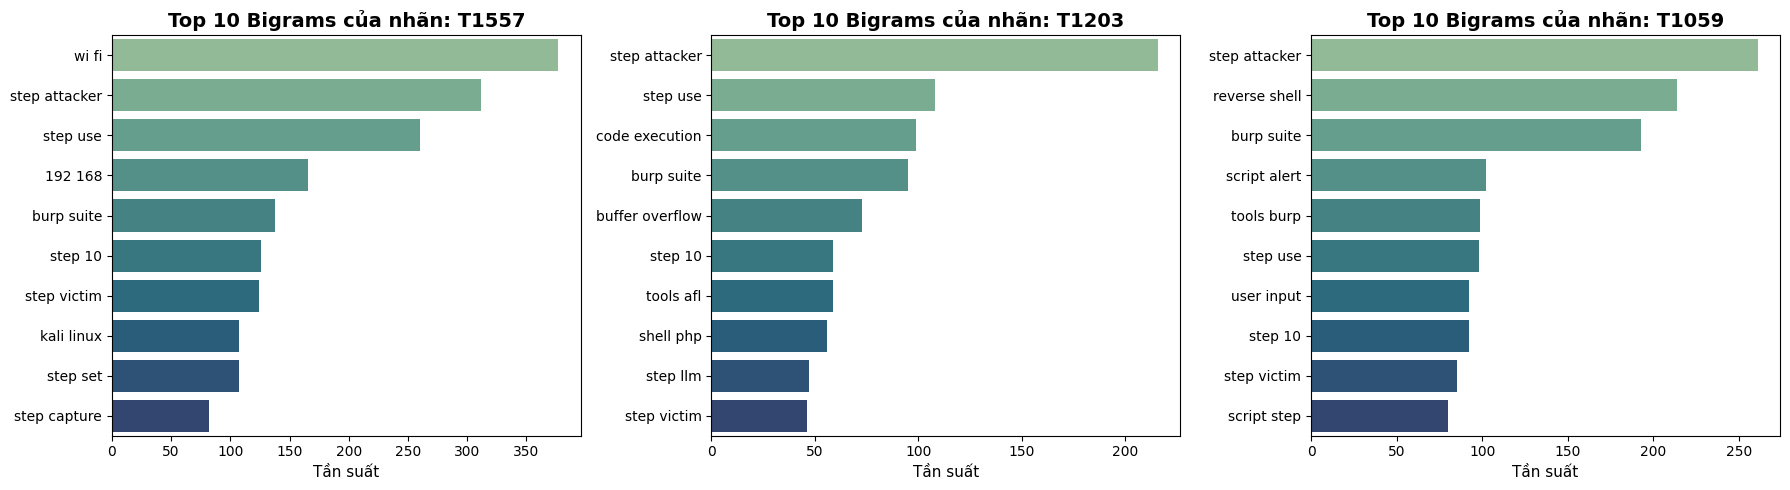

In [38]:
# Cell 7: Phân tích cụm từ khóa (Bigrams) đặc trưng cho Top 3 kỹ thuật
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lấy danh sách Top 3 nhãn xuất hiện nhiều nhất
top_3_labels = df_filtered['label'].value_counts().head(3).index

# Thiết lập khung biểu đồ (1 hàng, 3 cột)
plt.figure(figsize=(18, 5))

# Vòng lặp vẽ biểu đồ cho từng nhãn
for i, label in enumerate(top_3_labels, 1):
    # Lấy văn bản của riêng nhãn hiện tại
    text_data = df_filtered[df_filtered['label'] == label]['text']
    
    # Khởi tạo bộ đếm cụm 2 từ (Bigram), loại bỏ từ vô nghĩa tiếng Anh mặc định
    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10)
    
    try:
        # Chuyển đổi văn bản thành ma trận đếm
        X = vectorizer.fit_transform(text_data)
        
        # Lấy danh sách từ và tổng tần suất
        words = vectorizer.get_feature_names_out()
        counts = X.sum(axis=0).A1
        
        # Tạo DataFrame và sắp xếp
        word_freq = pd.DataFrame({'Bigram': words, 'Count': counts}).sort_values(by='Count', ascending=False)
        
        # Vẽ biểu đồ con
        plt.subplot(1, 3, i)
        sns.barplot(x='Count', y='Bigram', data=word_freq, palette='crest')
        plt.title(f'Top 10 Bigrams của nhãn: {label}', fontsize=14, fontweight='bold')
        plt.xlabel('Tần suất', fontsize=11)
        plt.ylabel('')
    except ValueError:
        # Xử lý ngoại lệ nếu dữ liệu văn bản quá ngắn hoặc trống
        plt.subplot(1, 3, i)
        plt.title(f'Không đủ dữ liệu từ vựng cho: {label}')

plt.tight_layout()
plt.show()

BÁO CÁO SỐ LƯỢNG THỰC THỂ CTI TÌM THẤY:
--------------------------------------------------
- IPv4 Address             : 1,272 lần
- CVE ID (Mã lỗ hổng)      : 193 lần
- Windows File Path        : 537 lần
- Hash (MD5/SHA1/SHA256)   : 34 lần
--------------------------------------------------


C:\Users\84354\AppData\Local\Temp\ipykernel_14664\2296530494.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_entities.values()), y=list(sorted_entities.keys()), palette='rocket')


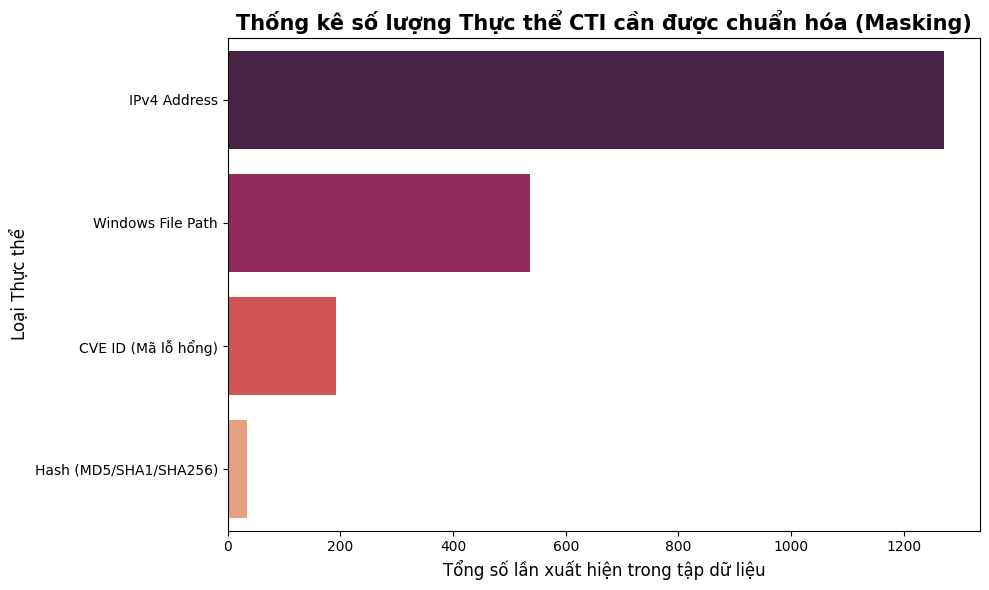

In [39]:
# Cell 8: Thống kê tần suất xuất hiện của các Thực thể An toàn thông tin
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Định nghĩa Regex (Biểu thức chính quy) cho các thực thể quan trọng
regex_patterns = {
    'IPv4 Address': r'\b(?:\d{1,3}\.){3}\d{1,3}\b',
    'CVE ID (Mã lỗ hổng)': r'CVE-\d{4}-\d{4,7}',
    'Windows File Path': r'[A-Za-z]:\\[^\s<>"\']+',
    'Hash (MD5/SHA1/SHA256)': r'\b[A-Fa-f0-9]{32}\b|\b[A-Fa-f0-9]{40}\b|\b[A-Fa-f0-9]{64}\b'
}

# 2. Hàm đếm số lượng thực thể trong một đoạn văn bản
def count_entities(text, pattern):
    return len(re.findall(pattern, str(text), re.IGNORECASE))

# 3. Quét toàn bộ tập dữ liệu (Dùng df_filtered từ cell trước)
entity_counts = {}
for entity_name, pattern in regex_patterns.items():
    # Áp dụng hàm đếm cho từng dòng và tính tổng
    total_count = df_filtered['text'].apply(lambda x: count_entities(x, pattern)).sum()
    entity_counts[entity_name] = total_count

# 4. In báo cáo chi tiết
print("BÁO CÁO SỐ LƯỢNG THỰC THỂ CTI TÌM THẤY:")
print("-" * 50)
for k, v in entity_counts.items():
    print(f"- {k:<25}: {v:,} lần")
print("-" * 50)

# 5. Vẽ biểu đồ trực quan
plt.figure(figsize=(10, 6))
# Sắp xếp lại dict theo value từ cao xuống thấp để biểu đồ đẹp hơn
sorted_entities = dict(sorted(entity_counts.items(), key=lambda item: item[1], reverse=True))

sns.barplot(x=list(sorted_entities.values()), y=list(sorted_entities.keys()), palette='rocket')
plt.title('Thống kê số lượng Thực thể CTI cần được chuẩn hóa (Masking)', fontsize=15, fontweight='bold')
plt.xlabel('Tổng số lần xuất hiện trong tập dữ liệu', fontsize=12)
plt.ylabel('Loại Thực thể', fontsize=12)
plt.tight_layout()
plt.show()

Đang vẽ phân cụm cho 5 nhãn: ['T1557', 'T1203', 'T1059', 'T1606', 'T1552']


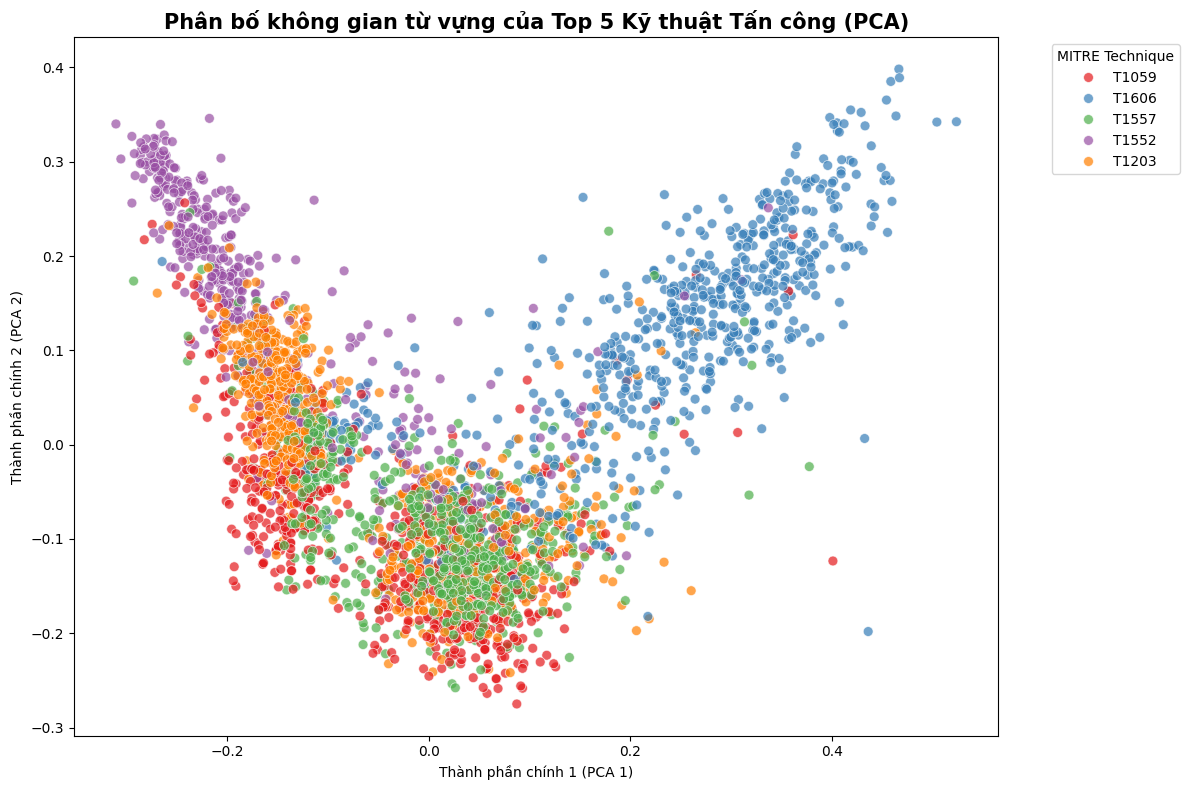

In [40]:
# Cell 9: Trực quan hóa không gian ngữ nghĩa (Semantic Space) bằng PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Để biểu đồ không bị nhiễu, chúng ta chỉ lấy Top 5 kỹ thuật phổ biến nhất để vẽ
top_5_labels = df_filtered['label'].value_counts().head(5).index
df_top5 = df_filtered[df_filtered['label'].isin(top_5_labels)].copy()

print(f"Đang vẽ phân cụm cho 5 nhãn: {list(top_5_labels)}")

# 1. Chuyển văn bản thành Vector TF-IDF (giới hạn 1000 từ quan trọng nhất)
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = tfidf.fit_transform(df_top5['text']).toarray()

# 2. Dùng PCA giảm từ 1000 chiều xuống còn 2 chiều (2D) để vẽ đồ thị
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf)

# Gắn tọa độ 2D ngược lại vào DataFrame
df_top5['pca_x'] = X_pca[:, 0]
df_top5['pca_y'] = X_pca[:, 1]

# 3. Vẽ biểu đồ Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_top5, 
    x='pca_x', y='pca_y', 
    hue='label', 
    palette='Set1', 
    alpha=0.7, 
    s=50
)
plt.title('Phân bố không gian từ vựng của Top 5 Kỹ thuật Tấn công (PCA)', fontsize=15, fontweight='bold')
plt.xlabel('Thành phần chính 1 (PCA 1)')
plt.ylabel('Thành phần chính 2 (PCA 2)')
plt.legend(title='MITRE Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

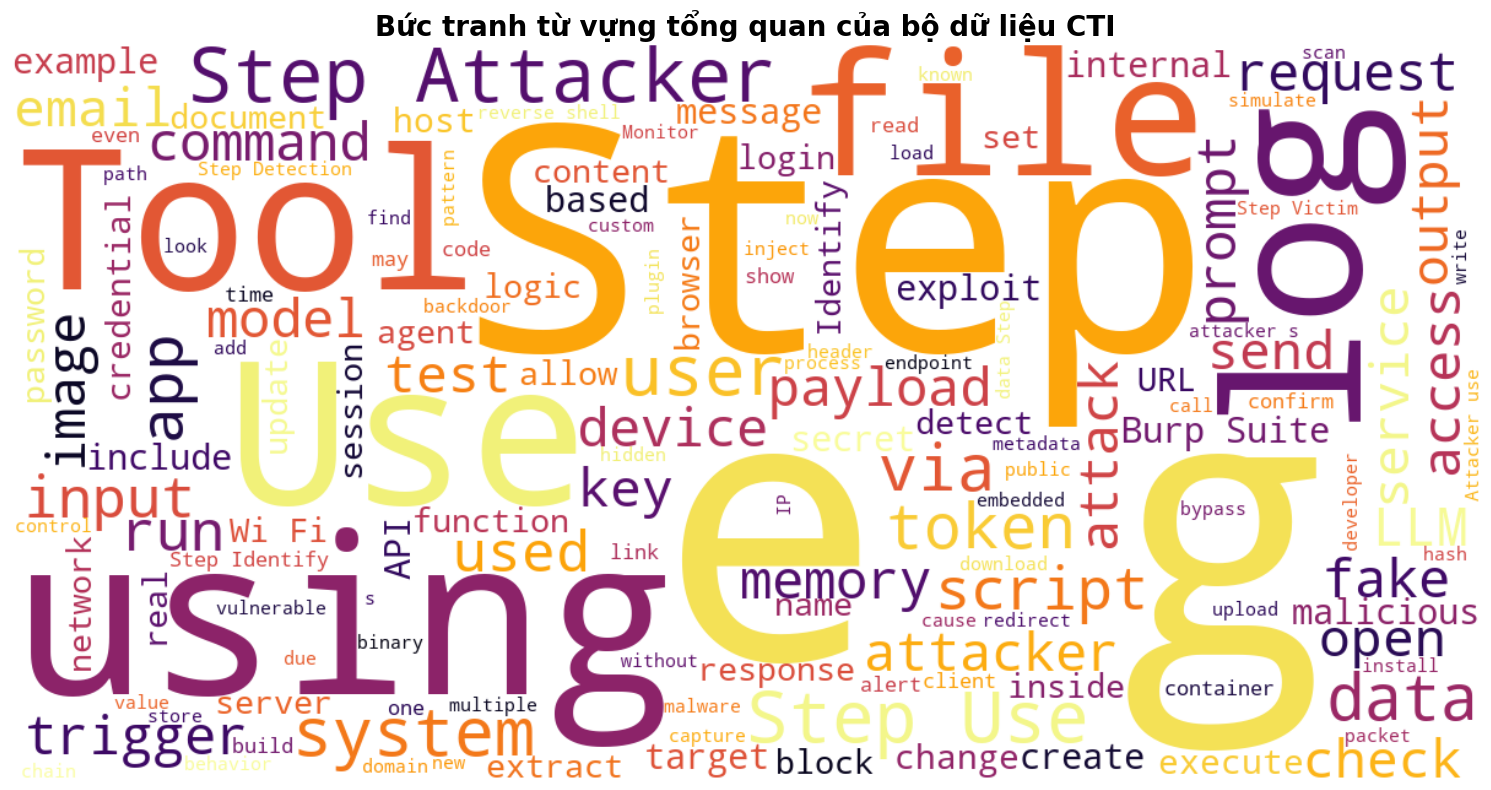

In [41]:
# Cell 10: Tạo Word Cloud (Đám mây từ vựng)
from wordcloud import WordCloud

# 1. Gộp toàn bộ văn bản trong tập dữ liệu (đã lọc) thành một chuỗi khổng lồ
all_text = " ".join(text for text in df_filtered['text'])

# 2. Khởi tạo WordCloud
# Tự động loại bỏ stopwords tiếng Anh mặc định
wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='white', 
    colormap='inferno',
    max_words=150, 
    contour_width=3, 
    contour_color='steelblue'
).generate(all_text)

# 3. Vẽ hiển thị
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Ẩn trục tọa độ
plt.title('Bức tranh từ vựng tổng quan của bộ dữ liệu CTI', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

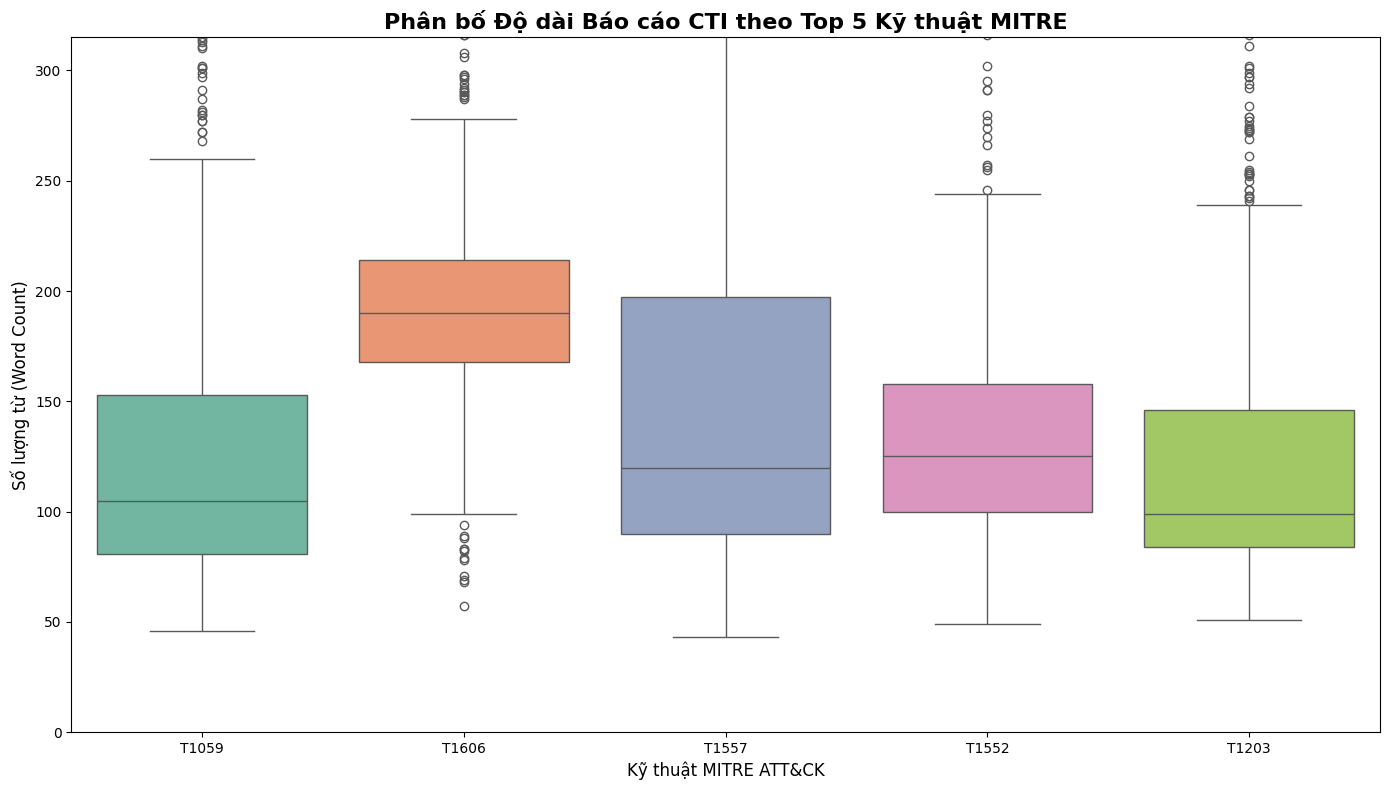

In [42]:
# Cell 11: Phân tích Phân bố Độ dài Văn bản theo Top 5 Nhãn (Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tính số từ (nếu chưa có từ các cell trước)
if 'word_count' not in df_filtered.columns:
    df_filtered['word_count'] = df_filtered['text'].apply(lambda x: len(str(x).split()))

# Lấy dữ liệu của Top 5 nhãn xuất hiện nhiều nhất
top_5_labels = df_filtered['label'].value_counts().head(5).index
df_top5 = df_filtered[df_filtered['label'].isin(top_5_labels)]

plt.figure(figsize=(14, 8))
# Vẽ boxplot để xem trung vị và các điểm ngoại lai (outliers)
sns.boxplot(
    x='label', 
    y='word_count', 
    data=df_top5, 
    hue='label', # Fix warning của Seaborn
    palette='Set2',
    legend=False
)

# Cắt bớt trục Y ở bách phân vị 95% để biểu đồ không bị bóp méo bởi vài văn bản quá dài
y_max = df_top5['word_count'].quantile(0.95)
plt.ylim(0, y_max)

plt.title('Phân bố Độ dài Báo cáo CTI theo Top 5 Kỹ thuật MITRE', fontsize=16, fontweight='bold')
plt.xlabel('Kỹ thuật MITRE ATT&CK', fontsize=12)
plt.ylabel('Số lượng từ (Word Count)', fontsize=12)
plt.tight_layout()
plt.show()

Đang tính toán ma trận TF-IDF và kiểm định Chi-Square...


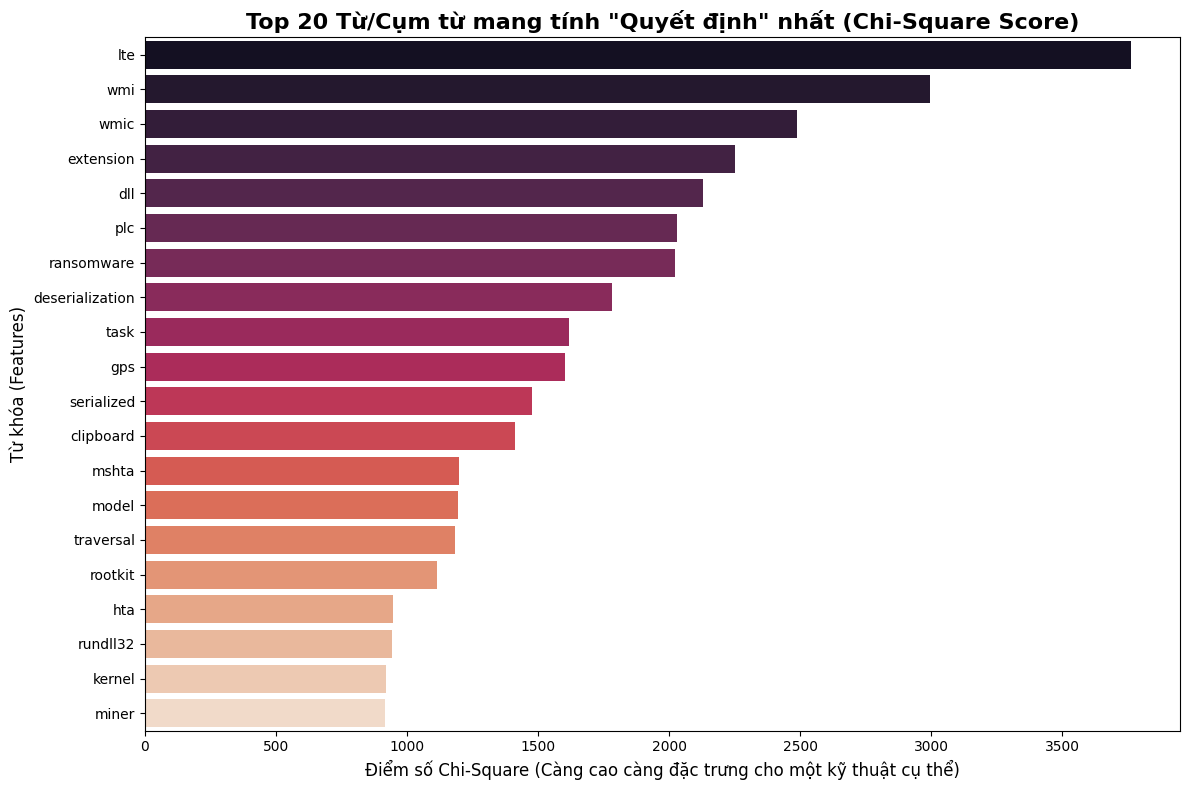

In [43]:
# Cell 12: Đánh giá tầm quan trọng của Từ khóa bằng Chi-Square Test
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
import numpy as np

print("Đang tính toán ma trận TF-IDF và kiểm định Chi-Square...")

# 1. Chuyển đổi nhãn (Text) thành số (IDs) để dùng với Chi-Square
y_encoded = pd.factorize(df_filtered['label'])[0]

# 2. Xây dựng TF-IDF Vectorizer (Bao gồm cả Unigram và Bigram)
tfidf = TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df_filtered['text'])

# Lấy danh sách 3000 từ vựng
feature_names = np.array(tfidf.get_feature_names_out())

# 3. Tính toán điểm Chi-Square cho từng từ vựng
chi2_scores, p_values = chi2(X_tfidf, y_encoded)

# 4. Sắp xếp và lấy Top 20 từ có điểm cao nhất
top_indices = np.argsort(chi2_scores)[::-1][:20]
top_features = feature_names[top_indices]
top_chi2_scores = chi2_scores[top_indices]

# 5. Trực quan hóa
plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_chi2_scores, 
    y=top_features, 
    hue=top_features,
    palette='rocket',
    legend=False
)
plt.title('Top 20 Từ/Cụm từ mang tính "Quyết định" nhất (Chi-Square Score)', fontsize=16, fontweight='bold')
plt.xlabel('Điểm số Chi-Square (Càng cao càng đặc trưng cho một kỹ thuật cụ thể)', fontsize=12)
plt.ylabel('Từ khóa (Features)', fontsize=12)
plt.tight_layout()
plt.show()

In [44]:
df_filtered.describe()

,ID,word_count
count,13161.000000,13161.000000
mean,6993.323076,137.977585
std,4076.523155,80.831187
min,1.000000,33.000000
25%,3454.000000,84.000000
50%,6987.000000,111.000000
75%,10531.000000,171.000000
max,14133.000000,1010.000000
